<a href="https://colab.research.google.com/github/vgandred-cmyk/colab-notebooks/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 152ms/step - accuracy: 0.7922 - loss: 0.4438 - val_accuracy: 0.8484 - val_loss: 0.3605
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9032 - loss: 0.2501 - val_accuracy: 0.8028 - val_loss: 0.4420
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.9275 - loss: 0.1884 - val_accuracy: 0.8738 - val_loss: 0.3457
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 148ms/step - accuracy: 0.9414 - loss: 0.1564 - val_accuracy: 0.8450 - val_loss: 0.3897
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.9637 - loss: 0.1038 - val_accuracy: 0.8430 - val_loss: 0.4657
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8359 - loss: 0.4919
Test Accuracy: 0.8358799815177917


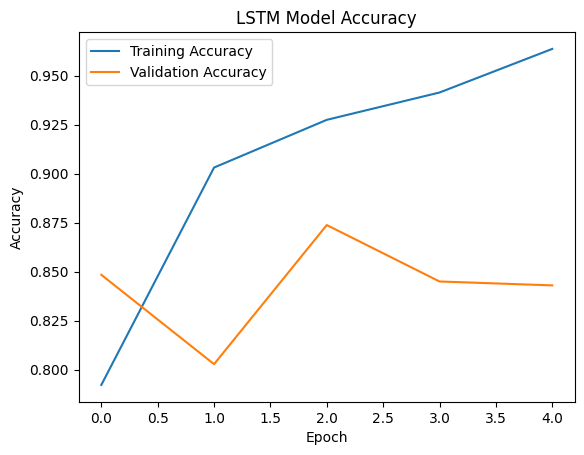

In [1]:
############
# LSTM for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (keep top 10,000 frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Make all reviews the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the LSTM model
model = Sequential()

# Embedding layer converts word numbers into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

# LSTM layer for learning long-term text patterns
model.add(LSTM(64))

# Output layer for binary sentiment classification
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

# Plot training accuracy
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()